# Seminární práce: Vliv rodinného zázemí a životního stylu na konečnou známku studenta z matematiky

## Tadeáš Pirich, 5. 6. 2026
## 4ST101 - Základy datových analýz


# Obsah

1. [Úvod](#sec-1-uvod)
2. [Teoretická část a metodologie](#sec-2-metodologie)
   - [Popisná statistika](#sec-21-popisna-statistika)
   - [Korelační analýza](#sec-22-korelace)
   - [Regresní analýza](#sec-23-regrese)
3. [Popis dat a návrh experimentu](#sec-3-data)
   - [Původ dat a jejich relevance](#sec-31-puvod)
   - [Výběr proměnných](#sec-32-vyber)
   - [Základní průzkum dat](#sec-33-pruzkum)
   - [Příprava a čištění dat](#sec-34-priprava)
4. [Praktická část a interpretace výsledků](#sec-4-prakticka)
   - [Vliv rodinného zázemí](#sec-41-rodinne)
     - [Vzdělání rodičů (Medu, Fedu)](#sec-411-medu-fedu)
     - [Povolání rodičů (Mjob, Fjob)](#sec-412-mjob-fjob)
   - [Vliv životního stylu](#sec-42-zivotni)
     - [Korelační analýza](#sec-421-korelace)
   - [Zobrazení celkového trendu (regrese)](#sec-43-regrese)
5. [Závěr a limity práce](#sec-5-zaver)
6. [Zdroje](#sec-references)


<a id="sec-1-uvod"></a>

# 1. Úvod

Úspěšnost studentů ve škole je ovlivňována řadou faktorů. Kromě samotných schopností studenta mohou hrát roli také podmínky v rodině, vzdělání a povolání rodičů, čas věnovaný přípravě do školy nebo životní styl. Zkoumání těchto souvislostí je důležité například proto, že může pomoci včas rozpoznat studenty, kteří jsou ohroženi horšími studijními výsledky, a nabídnout jim vhodnou podporu.

Tato práce se zaměřuje na vztah mezi rodinným zázemím, životním stylem studenta a jeho konečnou známkou z matematiky. Analýza vychází z datasetu **Student Performance**, který obsahuje údaje o studentech dvou portugalských středních škol. Data byla získána ze školních záznamů a dotazníků a zahrnují školní výsledky, demografické údaje, sociální faktory i informace o studijních návycích studentů (Cortez & Silva, 2008; University of California Irvine, 2014).

V práci bude jako hlavní sledovaná proměnná použita konečná známka z matematiky `G3`. Rodinné zázemí bude posuzováno podle vzdělání rodičů (`Medu`, `Fedu`) a jejich povolání (`Mjob`, `Fjob`). Životní styl bude sledován pomocí proměnné `studytime` a agregované proměnné `total_alcohol`, která váženě kombinuje konzumaci alkoholu v pracovních dnech (`Dalc`) a o víkendu (`Walc`) podle vzorce `(Dalc × 5 + Walc × 2) / 7`.

**Výzkumná otázka:** **Jaký vliv má rodinné zázemí v kombinaci se životním stylem studenta na jeho konečnou známku z matematiky?**

<a id="sec-2-metodologie"></a>

# 2. Teoretická část a metodologie

V této kapitole jsou popsány statistické metody, které budou v práci použity při analýze dat. Nejprve se podíváme na základní charakteristiky a vizualizace dat (včetně sloupcových grafů, váženého průměru a modu), poté na měření lineární závislosti mezi proměnnými včetně teplotní mapy korelační matice a nakonec na modelování vztahu pomocí regrese a bodového grafu.
<a id="sec-21-popisna-statistika"></a>

## 2.1 Popisná statistika

Popisná statistika slouží k tomu, abychom data nejprve lépe pochopili — zjistili, jak jsou hodnoty rozložené, kde leží jejich střed a jak moc se od sebe liší. V této práci ji využijeme zejména při průzkumu konečných známek z matematiky (`G3`) a vybraných proměnných rodinného zázemí a životního stylu.

### Histogram

Histogram je sloupcový graf, který ukazuje, jak často se v datech vyskytují jednotlivé hodnoty nebo intervaly hodnot. Osa $x$ představuje rozsah sledované proměnné a osa $y$ počet pozorování (frekvenci) v daném intervalu. Histogram nám pomůže rychle odhadnout tvar rozložení — například zda jsou známky soustředěné kolem určité hodnoty, nebo zda existují extrémní hodnoty.

### Sloupcový graf frekvencí

Na rozdíl od histogramu, který pracuje s intervaly hodnot, sloupcový graf frekvencí zobrazuje počet pozorování v jednotlivých diskrétních kategoriích. Osa $x$ představuje kategorie (např. úrovně vzdělání rodičů `Medu`, `Fedu`, kategorie času studia `studytime` nebo povolání `Mjob`, `Fjob`) a osa $y$ počet studentů v každé kategorii. Tento typ grafu použiji v kapitole 3.3 k porovnání struktury vzorku — tedy kolik studentů pochází z jakého socioekonomického prostředí.

### Aritmetický průměr

Aritmetický průměr je nejčastěji používaná míra centrální tendence. Vyjadřuje „typickou“ hodnotu v souboru dat jako součet všech hodnot dělený jejich počtem:

$$\bar{x} = \frac{1}{n} \sum_{i=1}^{n} x_i$$

kde $x_i$ jsou jednotlivá pozorování a $n$ je počet pozorování. Průměr je vhodný zejména u symetricky rozložených dat, ale může být ovlivněn extrémními hodnotami.

### Vážený průměr

Vážený průměr rozšiřuje aritmetický průměr o váhy, které vyjadřují relativní důležitost jednotlivých složek. Používá se, když jednotlivé hodnoty nepřispívají k výsledku stejnou měrou:

$$\bar{x}_w = \frac{\sum_{i=1}^{k} w_i x_i}{\sum_{i=1}^{k} w_i}$$

kde $x_i$ je hodnota $i$-té složky, $w_i$ je její váha a $k$ je počet složek. V této práci využiji vážený průměr při tvorbě proměnné `total_alcohol` — konzumaci alkoholu v pracovních dnech (`Dalc`) a o víkendu (`Walc`) sloučím vzorcem `(Dalc × 5 + Walc × 2) / 7`, kde váhy 5 a 2 odpovídají počtu pracovních a víkendových dnů v týdnu. Tím získám jednu proměnnou, která lépe reprezentuje celkovou konzumaci alkoholu než dvě oddělené škály.

### Medián

Medián je hodnota, která rozdělí seřazená data na dvě stejně velké poloviny — 50 % hodnot je menších nebo rovných mediánu a 50 % větších nebo rovných. Na rozdíl od průměru není citlivý na odlehlé hodnoty, proto je užitečný například u rozdělení známek, které nemusí být zcela symetrické.

Pro lichý počet pozorování:

$$\tilde{x} = x_{\left(\frac{n+1}{2}\right)}$$

Pro sudý počet pozorování:

$$\tilde{x} = \frac{x_{\left(\frac{n}{2}\right)} + x_{\left(\frac{n}{2}+1\right)}}{2}$$

### Modus

Modus (nejčastější hodnota) je hodnota, která se v souboru dat vyskytuje nejčastěji. U diskrétních proměnných, jako je konečná známka `G3`, modus ukazuje, jaká známka je ve vzorku nejběžnější. Spolu s průměrem a mediánem pomáhá posoudit tvar rozložení — například zda je rozložení soustředěné kolem jedné typické hodnoty, nebo zda obsahuje více vrcholů.

### Směrodatná odchylka

Směrodatná odchylka ($s$) měří průměrnou vzdálenost hodnot od aritmetického průměru — tedy jak moc se data typicky rozptylují kolem středu. Pro výběrový soubor dat se počítá jako:

$$s = \sqrt{\frac{1}{n-1} \sum_{i=1}^{n}(x_i - \bar{x})^2}$$

kde $x_i$ jsou jednotlivá pozorování, $\bar{x}$ je aritmetický průměr a $n$ je počet pozorování. Čím vyšší je $s$, tím větší je variabilita hodnot v souboru.

V této práci použiji směrodatnou odchylku při popisu rozložení konečných známek z matematiky (`G3`) v kapitole 3.3 — spolu s průměrem a mediánem pomáhá posoudit, zda jsou výsledky studentů spíše soustředěné kolem typické hodnoty, nebo zda se výrazně liší (např. kvůli studentům s velmi nízkými nebo vysokými známkami).

### krabicový graf (Boxplot)

Boxplot (krabicový graf) zobrazuje pět číselných souhrnů: minimum, první kvartil ($Q_1$), medián ($Q_2$), třetí kvartil ($Q_3$) a maximum. „Krabička“ v grafu vymezuje interval mezi $Q_1$ a $Q_3$, tedy středních 50 % dat. Délka krabičky odpovídá rozpětí mezi kvartily, tzv. interkvartilovému rozpětí:

$$IQR = Q_3 - Q_1$$

Boxplot je vhodný pro porovnání rozložení hodnot mezi různými skupinami — například jak se liší známky `G3` podle úrovně vzdělání rodičů nebo podle času věnovaného studiu.

<a id="sec-22-korelace"></a>

## 2.2 Korelační analýza

Korelační analýza zkoumá sílu a směr lineární vazby mezi dvěma kvantitativními proměnnými. V této práci ji použijeme k posouzení, zda například vyšší vzdělání rodičů nebo delší čas studia souvisí s lepší konečnou známkou z matematiky.

Nejčastěji se používá Pearsonův korelační koeficient:

$$r = \frac{\sum_{i=1}^{n}(x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum_{i=1}^{n}(x_i - \bar{x})^2 \cdot \sum_{i=1}^{n}(y_i - \bar{y})^2}}$$

Hodnota $r$ se pohybuje v intervalu $\langle -1; 1 \rangle$:

- $r \approx 1$ — silná kladná lineární souvislost
- $r \approx 0$ — slabá nebo žádná lineární souvislost
- $r \approx -1$ — silná záporná lineární souvislost

### Teplotní mapa (heatmapa)

Teplotní mapa (heatmapa) vizualizuje korelační matici — tabulku Pearsonových korelačních koeficientů mezi dvojicemi proměnných. Každá buňka matice je vybarvena podle síly a směru korelace (např. odstíny červené pro kladné hodnoty, modré pro záporné), přičemž v buňce je často uvedena i numerická hodnota $r$. Heatmapa umožňuje na jednom obrázku rychle porovnat vztahy mezi více proměnnými; v kapitole 4.2.1 ji použiji pro proměnné `studytime`, `total_alcohol` a `G3`.

Důležité je pamatovat, že korelace měří lineární vztah, nikoli příčinnost. Vysoká korelace tedy neznamená, že jedna proměnná přímo způsobuje změny druhé.

<a id="sec-23-regrese"></a>

## 2.3 Regresní analýza

Regresní analýza umožňuje modelovat závislost mezi vysvětlující proměnnou (prediktorem) $x$ a závislou proměnnou (cílovou proměnnou) $y$. V této práci ji použijeme k odhadu, jak se mění konečná známka z matematiky (`G3`) v závislosti na vybraných faktorech rodinného zázemí a životního stylu.

Základní model jednoduché lineární regrese má tvar:

$$y = \beta_0 + \beta_1 x + \varepsilon$$

kde $\beta_0$ je konstanta (intercept), $\beta_1$ je směrný koeficient a $\varepsilon$ je chyba modelu. Směrný koeficient $\beta_1$ vyjadřuje, o kolik se v průměru změní $y$ při zvýšení $x$ o jednu jednotku.

Koeficienty modelu se obvykle odhadují metodou nejmenších čtverců, která minimalizuje součet čtverců reziduí:

$$SSE = \sum_{i=1}^{n}(y_i - \hat{y}_i)^2$$

Kvalitu modelu lze posoudit pomocí koeficientu determinace:

$$R^2 = 1 - \frac{SSE}{SST}$$

kde $SST$ je celková variability závislé proměnné. Hodnota $R^2$ vyjadřuje, jakou část variability cílové proměnné model vysvětluje — čím blíže je 1, tím lépe model zapadá do dat.

### Bodový graf (scatter plot) a jitter

Bodový graf (scatter plot) zobrazuje jednotlivá pozorování jako body se souřadnicemi $(x_i, y_i)$. Při regresní analýze slouží k vizuální kontrole rozptylu dat a k znázornění odhadnuté regresní přímky, která reprezentuje celkový lineární trend.

U ordinálních proměnných s malým počtem kategorií (např. `studytime` s hodnotami 1–4) se body na ose $x$ často překrývají. Proto lze pro lepší čitelnost grafu použít jitter — drobný náhodný rozptyl bodů kolmo k ose $x$. Jitter nemění hodnoty proměnné v datasetu, slouží výhradně k vizualizaci rozložení pozorování v rámci jednotlivých kategorií. Tento postup použiji v kapitole 4.3 při zkoumání vztahu mezi časem na učení a konečnou známkou `G3`.


<a id="sec-3-data"></a>

## 3. Popis dat a návrh experimentu


<a id="sec-31-puvod"></a>

### 3.1 Původ dat a jejich relevance
Pro účely této práce jsem použil dataset *Student Performance* z UC Irvine Machine Learning Repository (Cortez & Silva, 2008; University of California Irvine, 2014). Dataset obsahuje údaje o studentech dvou portugalských středních škol a zaměřuje se na jejich výkon v předmětu matematika.

Kvalita a omezení dat:
Data jsou vysoce relevantní, protože kombinují jak objektivní školní výsledky, tak sociologické faktory získávané pomocí dotazníků (Nešpor, 2017). Je však nutné vzít v úvahu určitá omezení:
1. Kulturní kontext: Data pocházejí z Portugalska. Tamní školský systém a kulturní návyky se mohou od těch českých lišit (např. vnímání volného času či přístup k alkoholu).
2. Způsob sběru: Údaje o životním stylu (čas na učení, konzumace alkoholu) byly sbírány formou sebereflexe studentů v dotaznících — konzumace alkoholu na ordinální škále 1–5 u proměnných `Dalc` (pracovní dny) a `Walc` (víkend). Existuje zde tedy riziko, že si studenti u některých odpovědí data mírně "přikrášlili" (např. podhodnotili míru pití alkoholu).

<a id="sec-32-vyber"></a>

### 3.2 Výběr proměnných (Návrh experimentu)
Původní dataset obsahuje 33 různých atributů. Pro mou výzkumnou otázku jsem z datového souboru vybral následujících 8 klíčových proměnných, které jsem rozdělil do tří kategorií:

| Skupina | Název proměnné | Popis a škála hodnot |
| :--- | :--- | :--- |
| Cílová proměnná | G3 | Konečná známka z matematiky (0 - 20 bodů, čím více, tím lépe). |
| Rodinné zázemí | Medu / Fedu | Dosažené vzdělání matky / otce (0 = žádné, 4 = vysokoškolské). |
| | Mjob / Fjob | Povolání matky / otce (kategorie: školství, zdravotnictví, služby, doma, jiné). |
| Životní styl | studytime | Týdenní čas studia, zaznamenaný v kategoriích: 1 = méně než 2 hodiny, 2 = 2–5 hodin, 3 = 5–10 hodin, 4 = více než 10 hodin týdně. |
| | Dalc | Konzumace alkoholu během pracovních dnů (škála 1–5). |
| | Walc | Konzumace alkoholu o víkendu (škála 1–5). |

<a id="sec-33-pruzkum"></a>

### 3.3 Základní průzkum dat

Ještě než se pustíme do samotné analýzy, je vhodné podívat se na rozložení studentů v datasetu. Níže jsou zobrazeny čtyři oblasti průzkumu: histogram konečných známek z matematiky (`G3`), přehled vzdělání rodičů (`Medu`, `Fedu`), přehled povolání rodičů (`Mjob`, `Fjob`) a rozložení týdenního času studia (`studytime`).


In [15]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

# Dataset: UCI Student Performance (id=320), mathematics course
DATA_PATH = Path("data/student-mat.csv")

df = pd.read_csv(DATA_PATH, sep=";")

columns = [
    "Medu", "Fedu", "Mjob", "Fjob",
    "studytime", "Dalc", "Walc",
    "G3",
]
df = df[columns]

X = df.drop(columns="G3")
y = df[["G3"]]

print(f"Počet pozorování: {len(df)}")
print(f"Počet proměnných: {len(columns)}")
display(df.head())
display(df.describe())

Počet pozorování: 395
Počet proměnných: 8


,Medu,Fedu,Mjob,Fjob,studytime,Dalc,Walc,G3
0,4,4,at_home,teacher,2,1,1,6
1,1,1,at_home,other,2,1,1,6
2,1,1,at_home,other,2,2,3,10
3,4,2,health,services,3,1,1,15
4,3,3,other,other,2,1,2,10


,Medu,Fedu,studytime,Dalc,Walc,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,2.749367,2.521519,2.035443,1.481013,2.291139,10.415190
std,1.094735,1.088201,0.839240,0.890741,1.287897,4.581443
min,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000
25%,2.000000,2.000000,1.000000,1.000000,1.000000,8.000000
50%,3.000000,2.000000,2.000000,1.000000,2.000000,11.000000
75%,4.000000,3.000000,2.000000,2.000000,3.000000,14.000000
max,4.000000,4.000000,4.000000,5.000000,5.000000,20.000000


Popisná statistika konečné známky z matematiky (G3):


,hodnota
Aritmetický průměr (x̄),10.42
Medián,11.00
Modus (nejčastější známka),10.00
Směrodatná odchylka (s),4.58
1. kvartil (Q1),8.00
3. kvartil (Q3),14.00
Počet studentů s 0 body,38.00
Podíl studentů s 0 body (%),9.60


Nejčastější hodnoty známky:


,počet_studentů
G3,
10,56
11,47
0,38
15,33
8,32


Vzdělání matky (Medu):


...

Vzdělání otce (Fedu):


,popis,počet_studentů,podíl (%)
Fedu,,,
0,0 – žádné,2,0.5
1,1 – základní,82,20.8
2,2 – 5.–9. třída,115,29.1
3,3 – střední,100,25.3
4,4 – vysokoškolské,96,24.3


Studenti s matkou se střední nebo vysokoškolským vzděláním (úroveň 3–4): 230 (58.2 %)
Studenti s otcem se střední nebo vysokoškolským vzděláním (úroveň 3–4): 196 (49.6 %)
Týdenní čas studia (studytime):


,popis,počet_studentů,podíl (%)
studytime,,,
1,1 – méně než 2 h,105,26.6
2,2 – 2–5 h,198,50.1
3,3 – 5–10 h,65,16.5
4,4 – více než 10 h,27,6.8


Nejčastější kategorie: 2 – 2–5 h (198 studentů, 50.1 %)


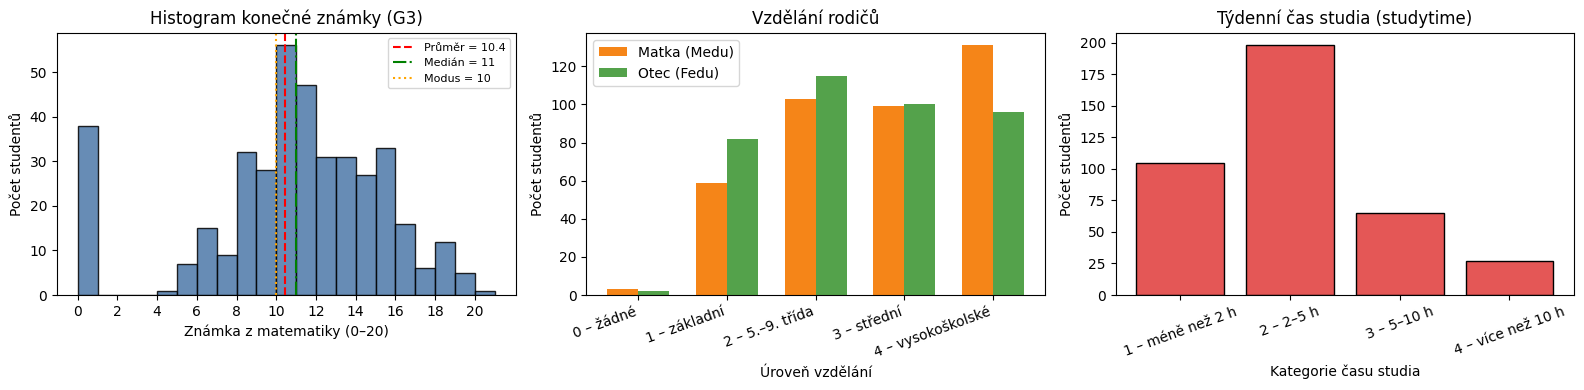

Povolání matky (Mjob):


,popis,počet_studentů,podíl (%)
Mjob,,,
other,jiné,141,35.7
services,služby,103,26.1
at_home,doma,59,14.9
teacher,učitel/ka,58,14.7
health,zdravotnictví,34,8.6


Povolání otce (Fjob):


,popis,počet_studentů,podíl (%)
Fjob,,,
other,jiné,217,54.9
services,služby,111,28.1
teacher,učitel/ka,29,7.3
at_home,doma,20,5.1
health,zdravotnictví,18,4.6


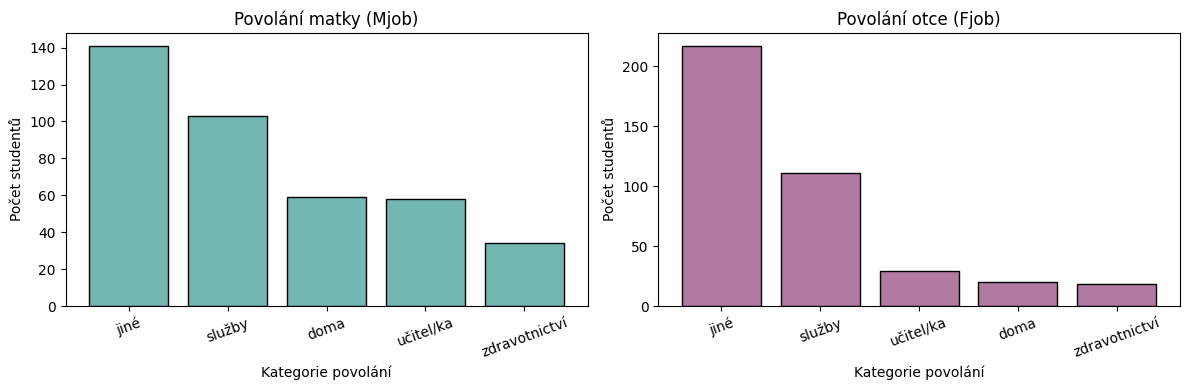

In [16]:
EDU_LABELS = {
    0: "0 – žádné",
    1: "1 – základní",
    2: "2 – 5.–9. třída",
    3: "3 – střední",
    4: "4 – vysokoškolské",
}

STUDYTIME_LABELS = {
    1: "1 – méně než 2 h",
    2: "2 – 2–5 h",
    3: "3 – 5–10 h",
    4: "4 – více než 10 h",
}

JOB_LABELS = {
    "teacher": "učitel/ka",
    "health": "zdravotnictví",
    "services": "služby",
    "at_home": "doma",
    "other": "jiné",
}

# Popisná statistika G3 — podklad pro interpretaci histogramu
g3 = df["G3"]
g3_mean = g3.mean()
g3_median = g3.median()
g3_mode = int(g3.mode().iloc[0])
g3_std = g3.std()
g3_q1 = g3.quantile(0.25)
g3_q3 = g3.quantile(0.75)
g3_zero_count = (g3 == 0).sum()
g3_zero_share = g3_zero_count / len(g3) * 100

g3_summary = pd.DataFrame(
    {
        "hodnota": [
            round(g3_mean, 2),
            g3_median,
            g3_mode,
            round(g3_std, 2),
            g3_q1,
            g3_q3,
            g3_zero_count,
            round(g3_zero_share, 1),
        ]
    },
    index=[
        "Aritmetický průměr (x̄)",
        "Medián",
        "Modus (nejčastější známka)",
        "Směrodatná odchylka (s)",
        "1. kvartil (Q1)",
        "3. kvartil (Q3)",
        "Počet studentů s 0 body",
        "Podíl studentů s 0 body (%)",
    ],
)

print("Popisná statistika konečné známky z matematiky (G3):")
display(g3_summary)

print("Nejčastější hodnoty známky:")
display(g3.value_counts().head(5).to_frame("počet_studentů"))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1. Histogram konečné známky (G3)
axes[0].hist(g3, bins=range(0, 22), edgecolor="black", color="#4C78A8", alpha=0.85)
axes[0].axvline(g3_mean, color="red", linestyle="--", linewidth=1.5, label=f"Průměr = {g3_mean:.1f}")
axes[0].axvline(g3_median, color="green", linestyle="-.", linewidth=1.5, label=f"Medián = {g3_median:.0f}")
axes[0].axvline(g3_mode, color="orange", linestyle=":", linewidth=1.5, label=f"Modus = {g3_mode}")
axes[0].set_title("Histogram konečné známky (G3)")
axes[0].set_xlabel("Známka z matematiky (0–20)")
axes[0].set_ylabel("Počet studentů")
axes[0].set_xticks(range(0, 21, 2))
axes[0].legend(fontsize=8)

# Počty vzdělání rodičů — podklad pro interpretaci grafu Medu a Fedu
n_students = len(df)

medu_table = (
    df["Medu"]
    .value_counts()
    .sort_index()
    .rename("počet_studentů")
    .to_frame()
)
medu_table["popis"] = medu_table.index.map(EDU_LABELS)
medu_table["podíl (%)"] = (medu_table["počet_studentů"] / n_students * 100).round(1)

fedu_table = (
    df["Fedu"]
    .value_counts()
    .sort_index()
    .rename("počet_studentů")
    .to_frame()
)
fedu_table["popis"] = fedu_table.index.map(EDU_LABELS)
fedu_table["podíl (%)"] = (fedu_table["počet_studentů"] / n_students * 100).round(1)

print("Vzdělání matky (Medu):")
display(medu_table[["popis", "počet_studentů", "podíl (%)"]])

print("Vzdělání otce (Fedu):")
display(fedu_table[["popis", "počet_studentů", "podíl (%)"]])

medu_high_edu = medu_table.loc[medu_table.index >= 3, "počet_studentů"].sum()
fedu_high_edu = fedu_table.loc[fedu_table.index >= 3, "počet_studentů"].sum()
print(
    f"Studenti s matkou se střední nebo vysokoškolským vzděláním (úroveň 3–4): "
    f"{medu_high_edu} ({medu_high_edu / n_students * 100:.1f} %)"
)
print(
    f"Studenti s otcem se střední nebo vysokoškolským vzděláním (úroveň 3–4): "
    f"{fedu_high_edu} ({fedu_high_edu / n_students * 100:.1f} %)"
)

# 2. Sloupcový graf vzdělání rodičů (Medu a Fedu)
edu_levels = sorted(df["Medu"].unique())
edu_labels = [EDU_LABELS[level] for level in edu_levels]
medu_counts = df["Medu"].value_counts().reindex(edu_levels, fill_value=0)
fedu_counts = df["Fedu"].value_counts().reindex(edu_levels, fill_value=0)

x = range(len(edu_levels))
width = 0.35
axes[1].bar([i - width / 2 for i in x], medu_counts, width=width, label="Matka (Medu)", color="#F58518")
axes[1].bar([i + width / 2 for i in x], fedu_counts, width=width, label="Otec (Fedu)", color="#54A24B")
axes[1].set_title("Vzdělání rodičů")
axes[1].set_xlabel("Úroveň vzdělání")
axes[1].set_ylabel("Počet studentů")
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(edu_labels, rotation=20, ha="right")
axes[1].legend()

# Počty času studia — podklad pro interpretaci grafu studytime
study_table = (
    df["studytime"]
    .value_counts()
    .sort_index()
    .rename("počet_studentů")
    .to_frame()
)
study_table["popis"] = study_table.index.map(STUDYTIME_LABELS)
study_table["podíl (%)"] = (study_table["počet_studentů"] / n_students * 100).round(1)

print("Týdenní čas studia (studytime):")
display(study_table[["popis", "počet_studentů", "podíl (%)"]])

most_common_study = study_table["počet_studentů"].idxmax()
print(
    f"Nejčastější kategorie: {STUDYTIME_LABELS[most_common_study]} "
    f"({study_table.loc[most_common_study, 'počet_studentů']} studentů, "
    f"{study_table.loc[most_common_study, 'podíl (%)']} %)"
)

# 3. Sloupcový graf času na učení (studytime)
study_levels = sorted(df["studytime"].unique())
study_labels = [STUDYTIME_LABELS[level] for level in study_levels]
study_counts = df["studytime"].value_counts().reindex(study_levels, fill_value=0)

axes[2].bar(study_labels, study_counts, color="#E45756", edgecolor="black")
axes[2].set_title("Týdenní čas studia (studytime)")
axes[2].set_xlabel("Kategorie času studia")
axes[2].set_ylabel("Počet studentů")
axes[2].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

# Počty povolání rodičů — podklad pro interpretaci grafu Mjob a Fjob
mjob_table = (
    df["Mjob"]
    .value_counts()
    .sort_values(ascending=False)
    .rename("počet_studentů")
    .to_frame()
)
mjob_table["popis"] = mjob_table.index.map(JOB_LABELS)
mjob_table["podíl (%)"] = (mjob_table["počet_studentů"] / n_students * 100).round(1)

fjob_table = (
    df["Fjob"]
    .value_counts()
    .sort_values(ascending=False)
    .rename("počet_studentů")
    .to_frame()
)
fjob_table["popis"] = fjob_table.index.map(JOB_LABELS)
fjob_table["podíl (%)"] = (fjob_table["počet_studentů"] / n_students * 100).round(1)

print("Povolání matky (Mjob):")
display(mjob_table[["popis", "počet_studentů", "podíl (%)"]])

print("Povolání otce (Fjob):")
display(fjob_table[["popis", "počet_studentů", "podíl (%)"]])

# Sloupcové grafy povolání rodičů (Mjob a Fjob)
fig_jobs, axes_jobs = plt.subplots(1, 2, figsize=(12, 4))

mjob_order = mjob_table.index.tolist()
mjob_labels = [JOB_LABELS[job] for job in mjob_order]
mjob_counts = mjob_table["počet_studentů"].reindex(mjob_order)

fjob_order = fjob_table.index.tolist()
fjob_labels = [JOB_LABELS[job] for job in fjob_order]
fjob_counts = fjob_table["počet_studentů"].reindex(fjob_order)

axes_jobs[0].bar(mjob_labels, mjob_counts, color="#72B7B2", edgecolor="black")
axes_jobs[0].set_title("Povolání matky (Mjob)")
axes_jobs[0].set_xlabel("Kategorie povolání")
axes_jobs[0].set_ylabel("Počet studentů")
axes_jobs[0].tick_params(axis="x", rotation=20)

axes_jobs[1].bar(fjob_labels, fjob_counts, color="#B279A2", edgecolor="black")
axes_jobs[1].set_title("Povolání otce (Fjob)")
axes_jobs[1].set_xlabel("Kategorie povolání")
axes_jobs[1].set_ylabel("Počet studentů")
axes_jobs[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

#### Interpretace grafů

**Histogram konečné známky (G3)**  
Z histogramu i z vypočtené popisné statistiky je patrné, že většina studentů dosáhla známky přibližně v rozmezí 10–12 bodů. Aritmetický průměr činí přibližně 10,4 bodu, medián 11 bodů a nejčastější hodnotou (modus) je 10 bodů. Rozložení tedy není zcela symetrické — výsledky jsou soustředěny spíše k průměrným až lepším známkám, přičemž průměr je mírně nižší než medián. Zároveň je zde patrný sekundární vrchol kolem 0 bodů (38 studentů, tj. přibližně 9,6 % vzorku), což pravděpodobně odpovídá studentům, kteří předmět nezvládli, propadli nebo nebyli klasifikováni. Tato skupina může v další analýze významně ovlivnit výsledky.

**Vzdělání rodičů (Medu, Fedu)**  
Sloupcový graf ukazuje, z jakého socioekonomického prostředí studenti v našem vzorku pocházejí. U obou rodičů převažují vyšší úrovně vzdělání — nejčastěji se vyskytuje střední (úroveň 3) až vysokoškolské vzdělání (úroveň 4). U matek je podíl vysokoškolského vzdělání nejvyšší (131 studentů), u otců je rozložení o něco vyrovnanější a častěji se objevuje nižší vzdělání (zejména úroveň 1 a 2). Celkově lze říci, že vzorek studentů pochází převážně z rodin se střední a vyšší úrovní vzdělání, nikoli z prostředí s velmi nízkým vzděláním rodičů.

**Povolání rodičů (Mjob, Fjob)**  
U matek jsou nejčastější kategorie povolání „jiné“ (141 studentů), „služby“ (103) a „doma“ (59). U otců výrazně dominuje kategorie „jiné“ (217 studentů), následovaná „služby“ (111). Kategorie „učitel/ka“ a „zdravotnictví“ jsou u obou rodičů méně časté. Rozložení povolání tedy doplňuje obraz rodinného zázemí získaný z vzdělání rodičů — vzorek zahrnuje široké spektrum profesí, přičemž u otců je podíl kategorie „jiné“ obzvláště vysoký.

**Týdenní čas studia (studytime)**  
Největší podíl studentů spadá do kategorie 2, tedy 2–5 hodin týdenního studia (198 studentů, tj. přibližně polovina vzorku). Druhou nejčastější skupinou jsou studenti s méně než 2 hodinami studia týdně (105 studentů). Naopak kategorie 3 (5–10 hodin) a zejména kategorie 4 (více než 10 hodin) jsou zastoupeny výrazně méně — pouze 65, resp. 27 studentů. Většina studentů tedy věnuje učení spíše střední množství času a jen menší část vzorku studuje intenzivněji.

<a id="sec-34-priprava"></a>

### 3.4 Příprava a čištění dat

1. **Výběr relevantních proměnných** — z původních 33 atributů jsem ponechal pouze 8 proměnných vybraných podle výzkumné otázky (viz kapitola 3.2): `Medu`, `Fedu`, `Mjob`, `Fjob`, `studytime`, `Dalc`, `Walc` a `G3`. Ostatní sloupce jsem z datového rámce odstranil. Počet pozorování (395 studentů) zůstal beze změny.

2. **Kontrola chybějících dat (missing values)** — v Pythonu jsem ověřil celistvost datasetu a absenci prázdných hodnot (NaN); číselné hodnoty, jako např. 0 bodů z matematiky, jsem neodstraňoval.
3. **Tvorba nových proměnných (agregace)** — jelikož dataset obsahuje pití alkoholu v pracovních dnech (`Dalc`) a o víkendu (`Walc`), rozhodl jsem se tyto proměnné zkombinovat do jedné nové proměnné `total_alcohol` jako vážený průměr: `total_alcohol = (Dalc × 5 + Walc × 2) / 7`, kde váha 5 odpovídá počtu pracovních dnů a váha 2 počtu víkendových dnů v týdnu.

In [17]:
# 3.4.1 Výběr relevantních proměnných
df_full = pd.read_csv(DATA_PATH, sep=";")

selected_columns = [
    "Medu", "Fedu", "Mjob", "Fjob",
    "studytime", "Dalc", "Walc",
    "G3",
]

print(f"Původní dataset: {df_full.shape[0]} řádků, {df_full.shape[1]} sloupců")
print(f"Vybrané proměnné ({len(selected_columns)}): {', '.join(selected_columns)}")

removed_columns = [col for col in df_full.columns if col not in selected_columns]
print(f"Odstraněné sloupce ({len(removed_columns)}): {', '.join(removed_columns)}")

df = df_full[selected_columns].copy()
print(f"\nRedukovaný dataset: {df.shape[0]} řádků, {df.shape[1]} sloupců")
display(df.head())

# 3.4.2 Kontrola chybějících hodnot
missing_values = df.isna().sum()
print("Počet chybějících hodnot (NaN) v jednotlivých sloupcích:")
display(missing_values.to_frame("počet_NaN"))

if missing_values.sum() == 0:
    print("V datasetu nejsou žádné chybějící hodnoty – není potřeba imputace ani mazání řádků.")
else:
    print("Dataset obsahuje chybějící hodnoty, které by bylo nutné dále řešit.")

# Záměrně ponechané extrémní, ale platné hodnoty (např. 0 bodů z matematiky)
zero_grades = (df["G3"] == 0).sum()
print(f"\nPočet studentů s 0 body z matematiky (G3): {zero_grades}")
print("Tyto záznamy jsme ponechali, protože 0 je platná známka, nikoli chybějící hodnota.")

# 3.4.3 Tvorba nové proměnné total_alcohol
# Vážený průměr: 5 pracovních dnů (Dalc) + 2 víkendové dny (Walc)
df["total_alcohol"] = ((df["Dalc"] * 5) + (df["Walc"] * 2)) / 7

print("\nNová proměnná total_alcohol = (Dalc × 5 + Walc × 2) / 7")
display(
    df[["Dalc", "Walc", "total_alcohol"]]
    .describe()
    .round(2)
)

# Aktualizace proměnných pro další analýzu
X = df.drop(columns="G3")
y = df[["G3"]]

print(f"\nPřipravený dataset pro analýzu: {df.shape[0]} řádků, {df.shape[1]} sloupců")
display(df.head())

Původní dataset: 395 řádků, 33 sloupců
Vybrané proměnné (8): Medu, Fedu, Mjob, Fjob, studytime, Dalc, Walc, G3
Odstraněné sloupce (25): school, sex, age, address, famsize, Pstatus, reason, guardian, traveltime, failures, schoolsup, famsup, paid, activities, nursery, higher, internet, romantic, famrel, freetime, goout, health, absences, G1, G2

Redukovaný dataset: 395 řádků, 8 sloupců


,Medu,Fedu,Mjob,Fjob,studytime,Dalc,Walc,G3
0,4,4,at_home,teacher,2,1,1,6
1,1,1,at_home,other,2,1,1,6
2,1,1,at_home,other,2,2,3,10
3,4,2,health,services,3,1,1,15
4,3,3,other,other,2,1,2,10


Počet chybějících hodnot (NaN) v jednotlivých sloupcích:


,počet_NaN
Medu,0
Fedu,0
Mjob,0
Fjob,0
studytime,0
Dalc,0
Walc,0
G3,0


V datasetu nejsou žádné chybějící hodnoty – není potřeba imputace ani mazání řádků.

Počet studentů s 0 body z matematiky (G3): 38
Tyto záznamy jsme ponechali, protože 0 je platná známka, nikoli chybějící hodnota.

Nová proměnná total_alcohol = (Dalc × 5 + Walc × 2) / 7


,Dalc,Walc,total_alcohol
count,395.00,395.00,395.00
mean,1.48,2.29,1.71
std,0.89,1.29,0.92
min,1.00,1.00,1.00
25%,1.00,1.00,1.00
50%,1.00,2.00,1.29
75%,2.00,3.00,2.29
max,5.00,5.00,5.00



Připravený dataset pro analýzu: 395 řádků, 9 sloupců


,Medu,Fedu,Mjob,Fjob,studytime,Dalc,Walc,G3,total_alcohol
0,4,4,at_home,teacher,2,1,1,6,1.000000
1,1,1,at_home,other,2,1,1,6,1.000000
2,1,1,at_home,other,2,2,3,10,2.285714
3,4,2,health,services,3,1,1,15,1.000000
4,3,3,other,other,2,1,2,10,1.285714


<a id="sec-4-prakticka"></a>

# 4. Praktická část a interpretace výsledků

V této kapitole odpovídáme na výzkumnou otázku: *Jaký vliv má rodinné zázemí v kombinaci se životním stylem studenta na jeho konečnou známku z matematiky?* Postup rozdělujeme do dvou hlavních částí — vliv rodinného zázemí a vliv životního stylu.

<a id="sec-41-rodinne"></a>

## 4.1 Vliv rodinného zázemí na prospěch

Rodinné zázemí posuzujeme pomocí čtyř proměnných, které mohou ovlivnit konečnou známku z matematiky (`G3`): vzdělání matky (`Medu`), vzdělání otce (`Fedu`), povolání matky (`Mjob`) a povolání otce (`Fjob`). K porovnání rozložení známek mezi skupinami studentů používáme krabicové grafy (boxploty), které zobrazují medián, kvartily i případné odlehlé hodnoty. Nejprve se zaměříme na vzdělání rodičů.

<a id="sec-411-medu-fedu"></a>

### 4.1.1 Vliv vzdělání rodičů (Medu a Fedu)

Proměnné `Medu` a `Fedu` vyjadřují nejvyšší dosažené vzdělání matky a otce na škále 0–4 (0 = žádné, 4 = vysokoškolské). Níže porovnáváme konečnou známku `G3` v jednotlivých skupinách podle úrovně vzdělání rodičů.

V datech se vyskytuje i kategorie 0 (žádné vzdělání), avšak jen u 3 studentů u `Medu` a 2 u `Fedu`, tedy u méně než 1 % vzorku. Tak malý počet pozorování neumožňuje spolehlivý závěr, proto ji v grafech a souhrnné tabulce nevyhodnocujeme samostatně a závěry vztahujeme na úrovně 1–4.

Medu: z grafů a tabulky vyloučeno 3 studentů s úrovní 0 – žádné
Fedu: z grafů a tabulky vyloučeno 2 studentů s úrovní 0 – žádné


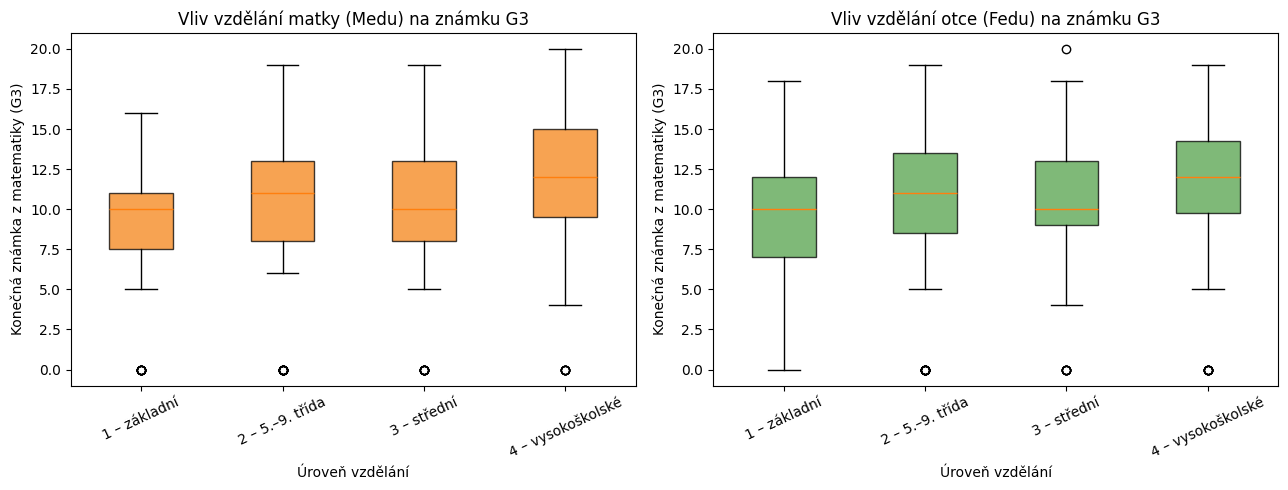


Popisná statistika G3 podle vzdělání rodičů (úrovně 1–4):


,proměnná,úroveň,počet_studentů,průměr_G3,medián_G3
0,Medu,1 – základní,59,8.68,10.0
1,Medu,2 – 5.–9. třída,103,9.73,11.0
2,Medu,3 – střední,99,10.30,10.0
3,Medu,4 – vysokoškolské,131,11.76,12.0
4,Fedu,1 – základní,82,9.16,10.0
5,Fedu,2 – 5.–9. třída,115,10.26,11.0
6,Fedu,3 – střední,100,10.66,10.0
7,Fedu,4 – vysokoškolské,96,11.36,12.0


In [18]:
# 4.1.1 Vliv vzdělání rodičů (Medu, Fedu) — boxploty G3
EDU_LABELS = {
    0: "0 – žádné",
    1: "1 – základní",
    2: "2 – 5.–9. třída",
    3: "3 – střední",
    4: "4 – vysokoškolské",
}

# Úroveň 0 vynecháváme — příliš malý vzorek (viz text výše)
MIN_EDU_LEVEL = 1

for column in ["Medu", "Fedu"]:
    excluded_count = (df[column] == 0).sum()
    if excluded_count:
        print(
            f"{column}: z grafů a tabulky vyloučeno "
            f"{excluded_count} studentů s úrovní 0 – žádné"
        )


def plot_g3_by_education(column, title, ax, color, min_level=MIN_EDU_LEVEL):
    levels = sorted(level for level in df[column].unique() if level >= min_level)
    groups = [df.loc[df[column] == level, "G3"] for level in levels]
    labels = [EDU_LABELS[level] for level in levels]

    boxplot = ax.boxplot(groups, tick_labels=labels, patch_artist=True)
    for patch in boxplot["boxes"]:
        patch.set_facecolor(color)
        patch.set_alpha(0.75)

    ax.set_title(title)
    ax.set_xlabel("Úroveň vzdělání")
    ax.set_ylabel("Konečná známka z matematiky (G3)")
    ax.tick_params(axis="x", rotation=25)


fig, axes = plt.subplots(1, 2, figsize=(13, 5))

plot_g3_by_education(
    "Medu",
    "Vliv vzdělání matky (Medu) na známku G3",
    axes[0],
    "#F58518",
)
plot_g3_by_education(
    "Fedu",
    "Vliv vzdělání otce (Fedu) na známku G3",
    axes[1],
    "#54A24B",
)

plt.tight_layout()
plt.show()


def education_g3_summary(column, variable_name, min_level=MIN_EDU_LEVEL):
    rows = []
    for level in sorted(level for level in df[column].unique() if level >= min_level):
        g3 = df.loc[df[column] == level, "G3"]
        rows.append(
            {
                "proměnná": variable_name,
                "úroveň": EDU_LABELS[level],
                "počet_studentů": len(g3),
                "průměr_G3": round(g3.mean(), 2),
                "medián_G3": g3.median(),
            }
        )
    return pd.DataFrame(rows)


print("\nPopisná statistika G3 podle vzdělání rodičů (úrovně 1–4):")
display(
    pd.concat(
        [
            education_g3_summary("Medu", "Medu"),
            education_g3_summary("Fedu", "Fedu"),
        ],
        ignore_index=True,
    )
)


#### Interpretace

Z krabicových grafů a souhrnné tabulky (úrovně 1–4) je patrný mírný vzestupný trend: s vyšším vzděláním rodičů roste medián i průměrná známka `G3`. U `Medu` stoupá medián z 10 bodů (úroveň 1) na 12 bodů (úroveň 4), u `Fedu` obdobně z 10 na 12 bodů. Zároveň se krabice jednotlivých skupin výrazně překrývají a v každé kategorii se vyskytují i studenti s velmi nízkými výsledky (včetně 0 bodů).
Vzdělání rodičů tedy samo o sobě konečnou známku z matematiky vysvětluje jen omezeně; výraznější vliv může ukázat až kombinace s dalšími faktory.

<a id="sec-412-mjob-fjob"></a>

### 4.1.2 Vliv povolání rodičů (Mjob a Fjob)

Proměnné `Mjob` a `Fjob` udávají povolání matky a otce v kategoriích: učitel/ka, zdravotnictví, služby, doma a jiné. Níže porovnáváme konečnou známku `G3` mezi těmito skupinami studentů pomocí krabicových grafů a souhrnné tabulky.

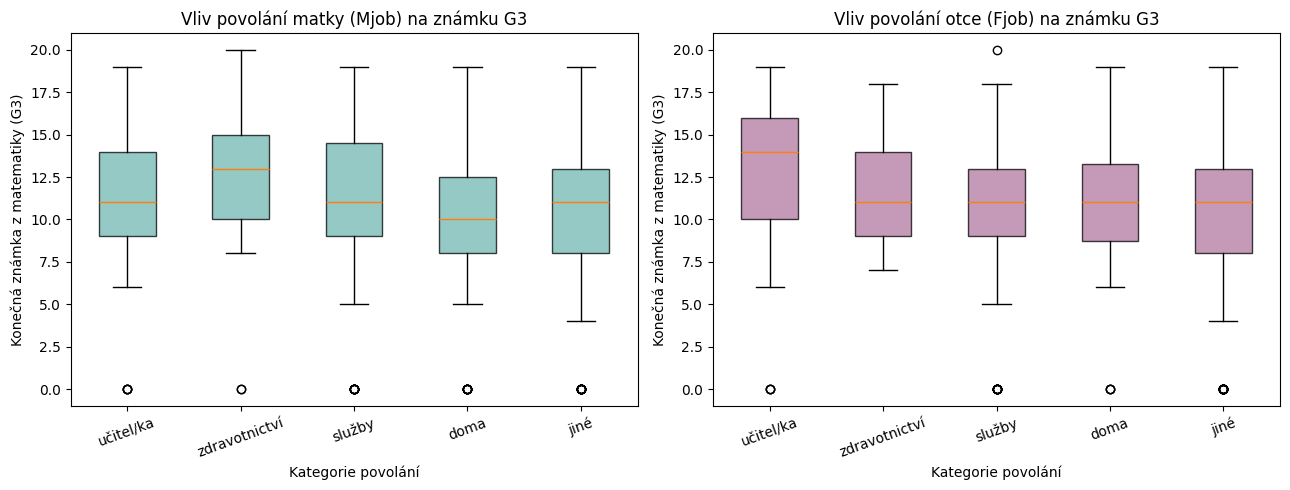

Popisná statistika G3 podle povolání rodičů:


,proměnná,kategorie,počet_studentů,průměr_G3,medián_G3
0,Mjob,učitel/ka,58,11.05,11.0
1,Mjob,zdravotnictví,34,12.15,13.0
2,Mjob,služby,103,11.02,11.0
3,Mjob,doma,59,9.15,10.0
4,Mjob,jiné,141,9.82,11.0
5,Fjob,učitel/ka,29,11.97,14.0
6,Fjob,zdravotnictví,18,11.61,11.0
7,Fjob,služby,111,10.30,11.0
8,Fjob,doma,20,10.15,11.0
9,Fjob,jiné,217,10.19,11.0


In [19]:
# 4.1.2 Vliv povolání rodičů (Mjob, Fjob) — boxploty G3
JOB_LABELS = {
    "teacher": "učitel/ka",
    "health": "zdravotnictví",
    "services": "služby",
    "at_home": "doma",
    "other": "jiné",
}

JOB_ORDER = ["teacher", "health", "services", "at_home", "other"]


def plot_g3_by_job(column, title, ax, color, job_order=JOB_ORDER):
    levels = [job for job in job_order if job in df[column].unique()]
    groups = [df.loc[df[column] == job, "G3"] for job in levels]
    labels = [JOB_LABELS[job] for job in levels]

    boxplot = ax.boxplot(groups, tick_labels=labels, patch_artist=True)
    for patch in boxplot["boxes"]:
        patch.set_facecolor(color)
        patch.set_alpha(0.75)

    ax.set_title(title)
    ax.set_xlabel("Kategorie povolání")
    ax.set_ylabel("Konečná známka z matematiky (G3)")
    ax.tick_params(axis="x", rotation=20)


fig, axes = plt.subplots(1, 2, figsize=(13, 5))

plot_g3_by_job(
    "Mjob",
    "Vliv povolání matky (Mjob) na známku G3",
    axes[0],
    "#72B7B2",
)
plot_g3_by_job(
    "Fjob",
    "Vliv povolání otce (Fjob) na známku G3",
    axes[1],
    "#B279A2",
)

plt.tight_layout()
plt.show()


def job_g3_summary(column, variable_name, job_order=JOB_ORDER):
    rows = []
    for job in [level for level in job_order if level in df[column].unique()]:
        g3 = df.loc[df[column] == job, "G3"]
        rows.append(
            {
                "proměnná": variable_name,
                "kategorie": JOB_LABELS[job],
                "počet_studentů": len(g3),
                "průměr_G3": round(g3.mean(), 2),
                "medián_G3": g3.median(),
            }
        )
    return pd.DataFrame(rows)


print("Popisná statistika G3 podle povolání rodičů:")
display(
    pd.concat(
        [
            job_g3_summary("Mjob", "Mjob"),
            job_g3_summary("Fjob", "Fjob"),
        ],
        ignore_index=True,
    )
)

#### Interpretace

Vliv povolání rodičů na známku `G3` se u matek a otců liší.

**Matky (`Mjob`)**  
Nejlepších výsledků dosahují studenti, jejichž matky pracují ve zdravotnictví — tabulka uvádí průměr 12,15 a medián 13,0, což je u všech kategorií nejvíce. V boxplotu je tento medián rovněž nejvýše. Naopak nejnižší hodnoty mají děti matek v domácnosti (kategorie „doma“): průměr 9,15 a medián 10,0.

**Otcové (`Fjob`)**  
U otců je obraz odlišný. Nejvyšší průměr (11,97) i medián (14,0) mají studenti s otci učiteli, což je v druhém boxplotu patrné na nejvýše posunuté krabici. Ostatní kategorie povolání se v průměru i mediánu pohybují přibližně kolem 10–11 bodů.

**Poznámka k velikosti vzorku**  
Při interpretaci výsledků u otců je vhodné brát v úvahu počet studentů v jednotlivých skupinách. Kategorie zdravotnictví (18 studentů), domácnost (20) a učitel/ka (29) jsou zastoupeny méně než např. „jiné“ (217 studentů), proto mohou být odhady méně stabilní. Celkově se však krabice jednotlivých kategorií u obou rodičů částečně překrývají, takže povolání samo o sobě konečnou známku z matematiky nevysvětluje jednoznačně.

<a id="sec-42-zivotni"></a>

## 4.2 Vliv životního stylu

V předchozí části jsme zkoumali vliv rodinného zázemí na konečnou známku z matematiky (`G3`). Nyní se zaměříme na faktory životního stylu, které student může přímo ovlivnit: týdenní čas věnovaný studiu (`studytime`) a agregovanou míru konzumace alkoholu (`total_alcohol`). Tyto proměnné popisují studijní návyky a volnočasové chování, jež mohou s prospěchem souviset nezávisle na sociálním původu.

<a id="sec-421-korelace"></a>

### 4.2.1 Korelační analýza

Pro zjištění síly lineárních vztahů mezi proměnnými životního stylu a konečnou známkou (`G3`) využívám Pearsonův korelační koeficient (viz kapitola 2.2). Výsledky jsou vizualizovány pomocí teplotní mapy (heatmapy), která znázorňuje korelační matici proměnných `studytime`, `total_alcohol` a `G3`.


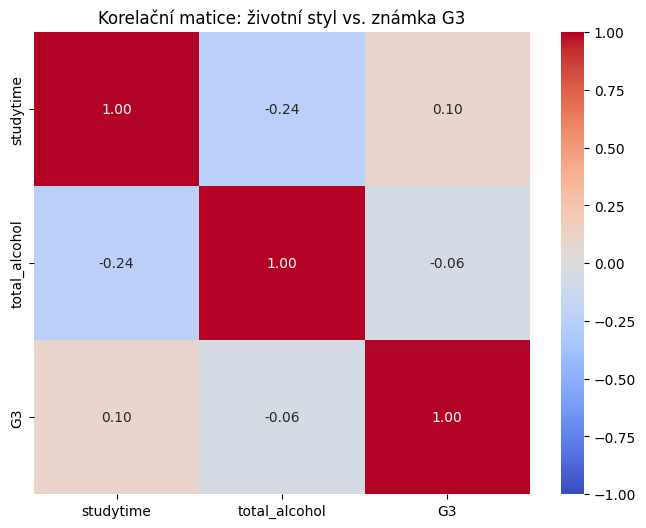

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

# Korelační matice proměnných životního stylu a cílové známky G3
korelacni_data = df[["studytime", "total_alcohol", "G3"]]
matice_korelaci = korelacni_data.corr()

# Teplotní mapa korelační matice
plt.figure(figsize=(8, 6))
sns.heatmap(matice_korelaci, annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1)
plt.title("Korelační matice: životní styl vs. známka G3")
plt.show()

#### Interpretace

**Čas na učení (`studytime`)**  
Mezi časem věnovaným učení a konečnou známkou `G3` existuje pouze velmi slabá pozitivní korelace (0,10). To naznačuje, že samotné prodlužování času stráveného nad učebnicemi automaticky nezaručuje lepší známku. V předmětu, jakým je matematika, pravděpodobně hraje mnohem větší roli přirozené nadání, pozornost v hodinách nebo předchozí znalosti z nižších ročníků.

**Konzumace alkoholu (`total_alcohol`)**  
Přímý vliv alkoholu na konečnou známku je v tomto vzorku téměř zanedbatelný (korelace −0,06).

**Nepřímý vliv alkoholu na učení**  
Nejvýraznější vztah v této matici (−0,24) pozorujeme mezi konzumací alkoholu a časem na učení. Studenti, kteří častěji konzumují alkohol, vykazují tendenci trávit méně času přípravou. Alkohol tedy zřejmě neovlivňuje známku přímo (např. zhoršením kognitivních funkcí při testu), ale spíše nepřímo — ubírá studentovi čas a motivaci ke studiu.

<a id="sec-43-regrese"></a>

## 4.3 Zobrazení celkového trendu (regrese)

Pro vizualizaci vztahu mezi týdenním časem studia (`studytime`) a konečnou známkou z matematiky (`G3`) používám bodový graf (scatter plot) s proloženou regresní přímkou odhadnutou metodou nejmenších čtverců (viz kapitola 2.3).

Proměnná `studytime` je ordinální a nabývá pouze čtyř hodnot (1–4). Aby se body v jednotlivých kategoriích nepřekrývaly a bylo patrné jejich rozložení, přidávám na ose $x$ drobný náhodný rozptyl (jitter). Regresní přímka pak znázorňuje celkový lineární trend — tedy zda delší čas věnovaný učení souvisí se zvýšením známky `G3`.

Doplňkově sleduji podíl studentů s nulovou známkou (`G3 = 0`) v jednotlivých kategoriích času studia. Hodnota 0 v datasetu pravděpodobně odpovídá studentům, kteří předmět nezvládli nebo nebyli klasifikováni (viz interpretace v kapitole 3.3).

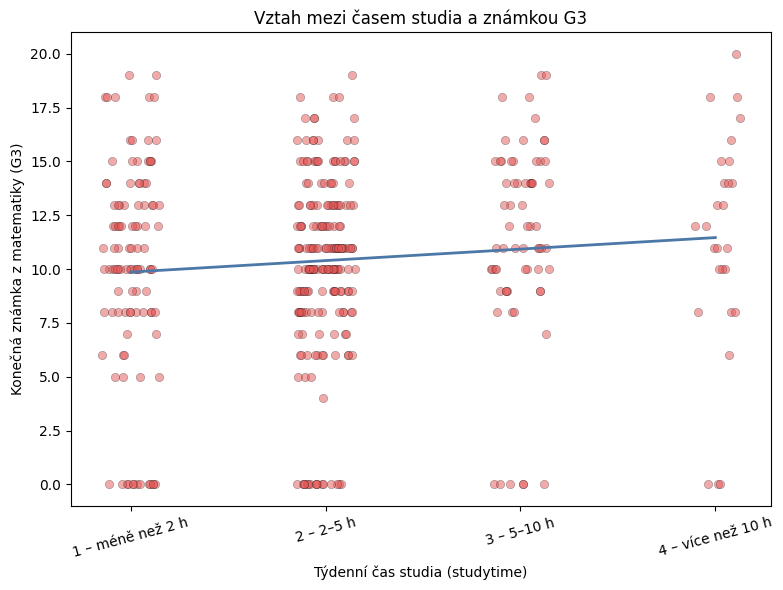

Regresní rovnice: G3 = 9.33 + 0.53 × studytime
Koeficient determinace R² = 0.010
Riziko propadnutí podle času na učení:


,popis,počet_studentů,počet_nul,podíl nul (%)
studytime,,,,
1,1 – méně než 2 h,105,13,12.4
2,2 – 2–5 h,198,16,8.1
3,3 – 5–10 h,65,6,9.2
4,4 – více než 10 h,27,3,11.1


In [21]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
ax = sns.regplot(
    data=df,
    x="studytime",
    y="G3",
    x_jitter=0.15,
    scatter_kws={
        "alpha": 0.5,
        "color": "#E45756",
        "edgecolor": "black",
        "linewidths": 0.3,
    },
    line_kws={"color": "#4C78A8", "linewidth": 2},
    ci=None,
)

study_levels = sorted(df["studytime"].unique())
ax.set_xticks(study_levels)
ax.set_xticklabels(
    [STUDYTIME_LABELS[level] for level in study_levels],
    rotation=15,
)
ax.set_xlabel("Týdenní čas studia (studytime)")
ax.set_ylabel("Konečná známka z matematiky (G3)")
ax.set_title("Vztah mezi časem studia a známkou G3")
plt.tight_layout()
plt.show()

slope, intercept = np.polyfit(df["studytime"], df["G3"], 1)
r_squared = df["studytime"].corr(df["G3"]) ** 2

print(f"Regresní rovnice: G3 = {intercept:.2f} + {slope:.2f} × studytime")
print(f"Koeficient determinace R² = {r_squared:.3f}")
# Analýza propadlíků (studentů s G3 == 0) podle času na učení
analyza_nul = (
    df.groupby("studytime")["G3"]
    .agg(
        počet_studentů="count",
        počet_nul=lambda x: (x == 0).sum(),
    )
    .sort_index()
)

analyza_nul["popis"] = analyza_nul.index.map(STUDYTIME_LABELS)
analyza_nul["podíl nul (%)"] = (
    analyza_nul["počet_nul"] / analyza_nul["počet_studentů"] * 100
).round(1)

print("Riziko propadnutí podle času na učení:")
display(
    analyza_nul[["popis", "počet_studentů", "počet_nul", "podíl nul (%)"]]
)


#### Interpretace

**Celkový trend**  
Modrá regresní přímka ukazuje mírný průměrný vzestupný trend, avšak koeficient determinace (R² = 0,010) potvrzuje, že tento vztah je velmi slabý. Skutečné rozložení dat není vidět v přímce, ale ve vertikálních shlucích bodů u jednotlivých kategorií `studytime`.

**1. Hustota studentů (šířka shluků)**  
Největší shluky pozorujeme v kategoriích 1 a 2 — většina studentů tedy studiu věnuje méně než 5 hodin týdně. Shluk u kategorie 4 (více než 10 hodin) je naopak řídký; tak intenzivně se učí jen malá menšina vzorku (27 studentů, tj. přibližně 6,8 %).

**2. Rozptyl známek (výška shluků)**  
V každém shluku jsou body roztažené téměř přes celou osu `G3`. I mezi studenty s nejnižším časem na učení (kategorie 1) se vyskytují jedinci s vynikajícími výsledky (blízko 20 bodům). Naopak ve skupině, která se učí poměrně dost (kategorie 3), najdeme i studenty s velmi špatnými výsledky.

**3. Riziko propadnutí (nulové známky)**  
V grafu je patrná horizontální řada bodů na hodnotě 0. Propadající studenti (`G3 = 0`) se vyskytují ve všech kategoriích; doplňková tabulka to kvantifikuje. Nejvyšší podíl nul je u kategorie 1 (12,4 %, 13 studentů), nejnižší u kategorie 2 (8,1 %). U kategorie 4 propadli 3 studenti (11,1 %), avšak vzhledem k malé velikosti skupiny je tento údaj třeba interpretovat opatrně.

**Závěr**  
Čas strávený učením sice mírně posouvá průměr (regresní přímku) směrem nahoru, ale u předmětu, jakým je matematika, existuje velké množství výjimek — samotný čas na učení není dostatečným prediktorem konečné známky. Z analýzy propadlíků zároveň vyplývá, že delší studium může částečně snižovat riziko úplného neúspěchu, ne však lineárně a jednoznačně ve všech kategoriích.

*Poznámka pod čarou: Drobný náhodný rozptyl bodů (jitter) ve scatter grafu slouží výhradně k vizualizaci — hodnoty proměnné `studytime` v datasetu se jím nemění.*


<a id="sec-5-zaver"></a>

# 5. Závěr a limity práce

Cílem této práce bylo odpovědět na výzkumnou otázku: *Jaký vliv má rodinné zázemí v kombinaci se životním stylem studenta na jeho konečnou známku z matematiky?* Postupoval jsem od popisu dat a teoretického vymezení použitých metod přes průzkum vzorku až k praktické analýze vlivu rodinného zázemí (`Medu`, `Fedu`, `Mjob`, `Fjob`) a životního stylu (`studytime`, `total_alcohol`) na cílovou proměnnou `G3`.

## 5.1 Shrnutí hlavních zjištění

Na základě provedených výpočtů, vizualizací a interpretací lze formulovat následující závěry.

**Rodinné zázemí jako podpůrný, nikoli rozhodující faktor**  
Z analýzy pomocí krabicových grafů a souhrnných tabulek vyplynulo, že socioekonomické prostředí rodiny ve výsledcích studentů hraje určitou roli, avšak ne natolik silnou, aby samo o sobě určovalo úspěch v matematice. U vzdělání rodičů (`Medu`, `Fedu`) lze pozorovat mírný vzestupný trend — medián `G3` roste z 10 bodů (úroveň 1) na 12 bodů (úroveň 4) — přičemž se rozložení známek v jednotlivých skupinách výrazně překrývá. U povolání rodičů se obraz liší podle pohlaví: studenti matek pracujících ve zdravotnictví dosahují nejvyššího průměru (12,15 bodu) a mediánu (13,0 bodu), zatímco u otců jsou nejlepší výsledky u kategorie učitel (průměr 11,97 bodu, medián 14,0 bodu). Zároveň se ve všech kategoriích vyskytují i studenti s velmi nízkými výsledky, včetně 0 bodů.

**Čas na učení: slabá pozitivní souvislost**  
Korelační a regresní analýza ukázaly, že delší čas věnovaný učení (`studytime`) souvisí s mírně vyšší konečnou známkou `G3` (Pearsonův korelační koeficient 0,10; regresní rovnice G3 = 9,33 + 0,53 × studytime). Tento vztah je však velmi slabý — koeficient determinace R² = 0,010 znamená, že čas na učení vysvětluje pouze přibližně 1 % variability známek. V předmětu, jakým je matematika, tedy samotná časová investice do studia výbornou známku nezaručuje; ve všech kategoriích `studytime` se vyskytují studenti s velmi odlišnými výsledky.

**Alkohol: zanedbatelný přímý vliv, možný nepřímý efekt**  
Celková konzumace alkoholu (`total_alcohol`) neměla v tomto vzorku na konečnou známku `G3` přímý výrazný dopad (korelace −0,06). Výraznější vztah se objevil mezi alkoholem a časem na učení (korelace −0,24): studenti s vyšší konzumací alkoholu tendenčně věnují méně času samostudiu. Alkohol tedy může ovlivňovat výsledek spíše nepřímo — prostřednictvím studijních návyků — než přímým působením na známku.

## 5.2 Odpověď na výzkumnou otázku

Rodinné zázemí i životní styl studenta s konečnou známkou z matematiky souvisí, avšak žádný ze sledovaných faktorů sám o sobě výsledek spolehlivě nevysvětluje. Rodinné prostředí (zejména vzdělání a vybraná povolání rodičů) poskytuje spíše podpůrný kontext — mírně zvyšuje průměrné výsledky, ale v každé skupině zůstává značná variabilita. Ze strany životního stylu hraje větší roli čas věnovaný učení než konzumace alkoholu, přičemž i delší studium zlepšuje známku jen okrajově. Kombinace obou oblastí naznačuje, že úspěch v matematice závisí na souhře více faktorů; v datech dominuje obraz velké heterogeneity výsledků uvnitř jednotlivých skupin studentů.

## 5.3 Limity práce

Při interpretaci výsledků je třeba zohlednit několik omezení:

1. **Geografický a kulturní kontext** — data pocházejí z portugalských středních škol; závěry nelze bez dalšího ověření přenášet na české prostředí.
2. **Observační charakter dat** — korelace a regrese popisují souvislosti, nikoli příčinné vztahy.
3. **Sebereflexe v dotaznících** — údaje o času na učení a konzumaci alkoholu vycházejí z odpovědí studentů a mohou být zkreslené.
4. **Velikost podskupin** — některé kategorie (např. `studytime` = 4, povolání rodičů) mají malý počet pozorování, což omezuje spolehlivost detailních závěrů.
5. **Výběr proměnných** — z původních 33 atributů bylo analyzováno osm; další faktory (např. předchozí známky `G1`, `G2`, docházka) nebyly součástí této práce.


<a id="sec-references"></a>

# Zdroje

Seznam použitých zdrojů je uváděn dle citačního stylu **APA 7**, který je preferovaným stylem na VŠE (viz [Citace – Knihovna VŠE](https://knihovna.vse.cz/citace/) a [Jak citovat ChatGPT a další GenAI](https://knihovna.vse.cz/citace/ai/)).

## Doplňkové materiály

Zdrojový kód analýz je dostupný v repozitáři na GitHubu (Pirich, 2026).

Pirich, T. (2026). *4ST101-Zaklady-datovych-analyz* [Source code]. GitHub. https://github.com/TadeasPir/4ST101-Zaklady-datovych-analyz

## Použitá literatura a datové zdroje

Cortez, P., & Silva, A. M. G. (2008). Using data mining to predict secondary school student performance. In *Proceedings of 5th Future Business Technology Conference (FUBUTEC 2008)* (pp. 5–12). EUROSIS.

Cortez, P., & Silva, A. M. G. (2008). *Student Performance* [Data set]. UCI Machine Learning Repository. https://archive.ics.uci.edu/dataset/320/student+performance

Nešpor, Z. R. (Ed.). (2017–). *Sociologická encyklopedie*. Sociologický ústav AV ČR. https://encyklopedie.soc.cas.cz/w/Hlavn%C3%AD_strana

University of California Irvine. (2014). *Student Performance* [Data set]. UCI Machine Learning Repository. https://archive.ics.uci.edu/dataset/320/student+performance

## Využití generativní umělé inteligence

Při přípravě semestrální práce byly využity nástroje generativní umělé inteligence. Konverzace *Způsob sběru dat* v nástroji **ChatGPT** (OpenAI, 2026a) sloužila k vyhledávání informací o datasetu, proměnných a statistických metodách. Konverzace *Brainstorming semestrální práce a datasetů* v nástroji **Gemini** (Google, 2026) byla využita k brainstormingu struktury práce a výběru datasetu. **Cursor** (Anysphere, 2026) byl využit při úpravě textu. Všechny výstupy byly autorem zkontrolovány a upraveny.

Anysphere. (2026). *Cursor* (Composer) [AI program]. https://cursor.com

Google. (2026a, 5. června). *Brainstorming semestrální práce a datasetů* [Generativní AI chat]. Gemini. https://gemini.google.com/share/78076dffbc21

OpenAI. (2026a, 6. června). *Způsob sběru dat* [Generativní AI chat]. ChatGPT. https://chatgpt.com/share/6a2da865-64e0-83eb-99a6-01298e00f7b8